In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"])
df.head()

,,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,
320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,Агентство,Шипиловская,"Шипиловская ул., 58к1",55.621211,37.745600,https://www.cian.ru/rent/commercial/320731003,['https://images.cdn-cian.ru/images/2592583348...,0.083,4.0,6.0,Офисное помещение,25.0
321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,Агентство,Аэропорт,"Ленинградский просп., 47С2",55.799036,37.532601,https://www.cian.ru/rent/commercial/321876001,['https://images.cdn-cian.ru/images/2631122267...,0.250,-2.0,7.0,Офисное помещение,25.0
322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,Агентство,Пролетарская,"Волгоградский просп., 2",55.731176,37.669279,https://www.cian.ru/rent/commercial/322186790,['https://images.cdn-cian.ru/images/2641248288...,0.250,6.0,16.0,Офисное помещение,20.0
321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,Частное лицо,Бунинская Аллея,"ул. Адмирала Руднева, 20",55.540409,37.516153,https://www.cian.ru/rent/commercial/321392086,['https://images.cdn-cian.ru/images/nezhiloe-p...,0.250,3.0,7.0,Торговое / Свободного назначения,32.0
324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,Агентство,Алексеевская,"просп. Мира, 95С1",55.808002,37.635853,https://www.cian.ru/rent/commercial/324943206,['https://images.cdn-cian.ru/images/ofis-moskv...,0.167,14.0,17.0,Офисное помещение,24.0


In [3]:
df.iloc[1].to_dict()

{'Название': 'Офис в Москва Ленинградский просп., 47С2 (25 м²)',
 'Цена': 31250,
 'Дата': Timestamp('2025-09-25 20:21:36'),
 'Тип автора': 'Агентство',
 'Метро/Район': 'Аэропорт',
 'Адрес': 'Ленинградский просп., 47С2',
 'lat': 55.799036,
 'lng': 37.532601,
 'URL': 'https://www.cian.ru/rent/commercial/321876001',
 'Ссылки на картинки': "['https://images.cdn-cian.ru/images/2631122267-1.jpg', 'https://images.cdn-cian.ru/images/2631122278-1.jpg', 'https://images.cdn-cian.ru/images/2631122298-1.jpg', 'https://images.cdn-cian.ru/images/2631122311-1.jpg', 'https://images.cdn-cian.ru/images/2631122329-1.jpg', 'https://images.cdn-cian.ru/images/2631122346-1.jpg', 'https://images.cdn-cian.ru/images/2631122367-1.jpg', 'https://images.cdn-cian.ru/images/2631122381-1.jpg', 'https://images.cdn-cian.ru/images/2631122401-1.jpg']",
 'Расстояние до метро, км': 0.25,
 'Этаж': -2.0,
 'Этажность здания': 7.0,
 'Вид объекта': 'Офисное помещение',
 'Общая площадь': 25.0}

In [2]:
df.dtypes

Название                           object
Цена                                int64
Дата                       datetime64[ns]
Тип автора                         object
Метро/Район                        object
Адрес                              object
lat                               float64
lng                               float64
URL                                object
Ссылки на картинки                 object
Расстояние до метро, км           float64
Этаж                              float64
Этажность здания                  float64
Вид объекта                        object
Общая площадь                     float64
dtype: object

In [3]:
df.columns

Index(['Название', 'Цена', 'Дата', 'Тип автора', 'Метро/Район', 'Адрес', 'lat',
       'lng', 'URL', 'Ссылки на картинки', 'Расстояние до метро, км', 'Этаж',
       'Этажность здания', 'Вид объекта', 'Общая площадь'],
      dtype='object')

In [4]:
df.isna().sum()

Название                     0
Цена                         0
Дата                         0
Тип автора                   0
Метро/Район                  0
Адрес                        4
lat                          0
lng                          0
URL                          0
Ссылки на картинки         148
Расстояние до метро, км      0
Этаж                       123
Этажность здания           128
Вид объекта                  1
Общая площадь                0
dtype: int64

In [5]:
df = df.dropna(subset="Вид объекта")

In [6]:
df["Метро/Район"].nunique()

315

# Трансформации

**Hack:** `OrdinalEncoder` нам создает некий ненужный порядок, которого у нас нет. Однако его можно ввести: достаточно понять влияние той или иной категории на таргет. Условно, делаем `TargetEncoding` -- назначаем метки по мере возрастания значения (дополнительно еще зашумляем и сглаживает). Так мы избегаем и сильной утечки таргета, и сохраняем важные данные.

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            # Заполним пропуски центральным значением (медианой)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, # OrdinalEncoder, TargetEncoder,
    StandardScaler, # MinMaxScaler, RobustScaler,
)


from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км", "Этаж"]),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), ["Вид объекта", "Тип автора"]),
        ("ordinal", OrdinalByTargetEncoder(), ["Метро/Район"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

In [9]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Этаж", "Вид объекта", "Тип автора", "Метро/Район"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [10]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Офисное помещение                   66.769593
Торговое / Свободного назначения    32.112925
Здание                               1.117483
Name: count, dtype: float64

In [11]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Офисное помещение                   66.754850
Торговое / Свободного назначения    32.098765
Здание                               1.146384
Name: count, dtype: float64

In [12]:
X_train.isna().sum()

Общая площадь               0
Расстояние до метро, км     0
Этаж                       93
Вид объекта                 0
Тип автора                  0
Метро/Район                 0
dtype: int64

In [13]:
X_test.isna().sum()

Общая площадь               0
Расстояние до метро, км     0
Этаж                       30
Вид объекта                 0
Тип автора                  0
Метро/Район                 0
dtype: int64

In [14]:
floor_mode = X_train["Этаж"].mode().values[0]
X_train["Этаж"] = X_train["Этаж"].fillna(floor_mode)
X_test["Этаж"] = X_test["Этаж"].fillna(floor_mode)

In [15]:
ct = ct.fit(X_train, y_train)
X_train_base = ct.transform(X_train)
X_test_base = ct.transform(X_test)

X_train_base

,,scale__Общая площадь,"scale__Расстояние до метро, км",scale__Этаж,onehot__Вид объекта_Здание,onehot__Вид объекта_Офисное помещение,onehot__Вид объекта_Торговое / Свободного назначения,onehot__Тип автора_Частное лицо,ordinal__Метро/Район
ID на сайте,Источник,,,,,,,,
320688808,cian.ru,-0.133625,-0.488892,4.997065,0.0,1.0,0.0,0.0,247
3940063262435011072,realty.yandex.ru,2.498412,-0.132344,1.556819,0.0,1.0,0.0,0.0,303
324402434,cian.ru,-0.768411,-0.261821,-0.449990,0.0,0.0,1.0,1.0,56
3255678710623666176,realty.yandex.ru,-0.535914,4.468557,-0.449990,0.0,0.0,1.0,0.0,122
323417609,cian.ru,0.797909,-0.294482,-0.306647,0.0,1.0,0.0,0.0,222
...,...,...,...,...,...,...,...,...,...
324977828,cian.ru,-0.690998,-0.197277,-0.449990,0.0,1.0,0.0,0.0,196
1736082285859492096,realty.yandex.ru,-0.835502,-0.132344,-0.019960,0.0,1.0,0.0,0.0,63
3087514413056855040,realty.yandex.ru,-0.786216,-0.100072,-0.306647,0.0,1.0,0.0,0.0,246


# Модель

In [16]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [ ]:
import sys

sys.path.append("..")

import viz

## Линейка

In [ ]:
model = LinearRegression().fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [20]:
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
optuna.logging.set_verbosity(optuna.logging.WARNING)


FIXED_KWARGS = {
    'tol': 1e-5,
    'random_state': 42,
}

CV = KFold(n_splits=5, random_state=10, shuffle=True)

def objective(trial, X, y):
    params = {
        'alpha': trial.suggest_float('alpha', low=0.0001, high=50),
        'max_iter': trial.suggest_int('max_iter', low=500, high=3000),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
    }
    
    params.update(FIXED_KWARGS)
    model = Ridge(**params).fit(X, y)
    scores = cross_validate(
        model,
        X, y,
        scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
        cv=CV,
        n_jobs=-1,
    )
    return scores['test_score'].mean()


def study_results(study):
    trial = study.best_trial
    print('Best CV={} score: {:.6}'.format(CV, trial.value))
    print('Best params:')
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))


def plot_study(study):
    fig_list = [
        optuna.visualization.plot_optimization_history(study),
        optuna.visualization.plot_param_importances(study),
    ]
    for fig in fig_list:
        fig.update_layout(width=900)
        fig.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Best CV=KFold(n_splits=5, random_state=10, shuffle=True) score: 0.72801
Best params:
    alpha: 23.015027636878404
    max_iter: 651
    solver: saga


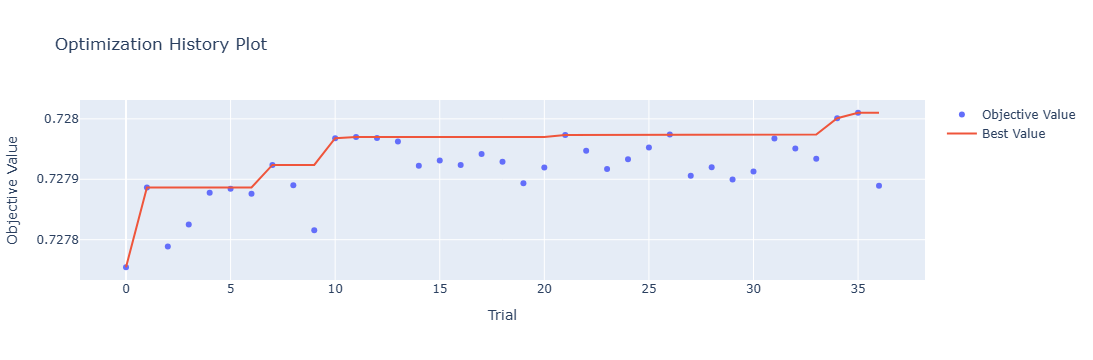

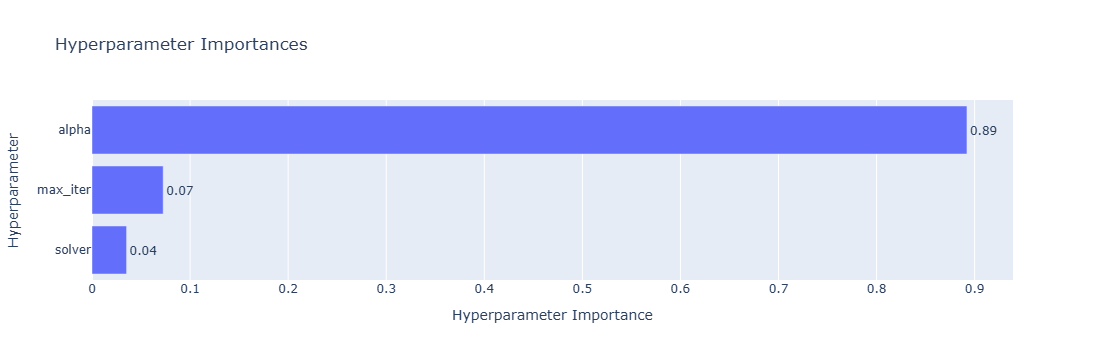

In [21]:
study = optuna.create_study(
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.HyperbandPruner(),
        direction="maximize",
)

study.optimize(lambda trial: objective(trial, X_train_base, y_train),
                  n_trials=1000, timeout=60, gc_after_trial=True, show_progress_bar=True)

study_results(study)
plot_study(study)

C:\Users\User\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



train metrics:
	  R2: 72.94%
	RMSE: 748403.37 руб.
	MAPE: 94.08%

test metrics:
	  R2: 73.08%
	RMSE: 744189.82 руб.
	MAPE: 91.66%


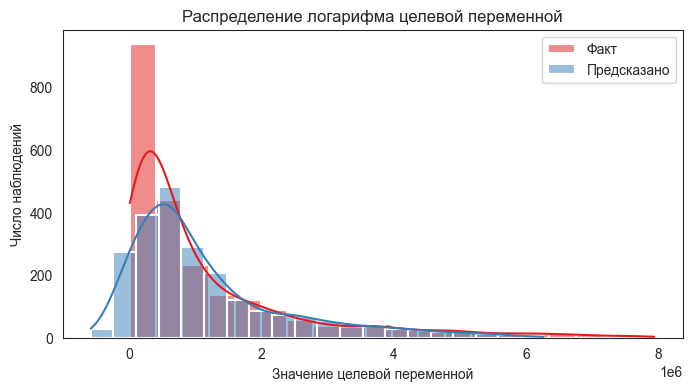

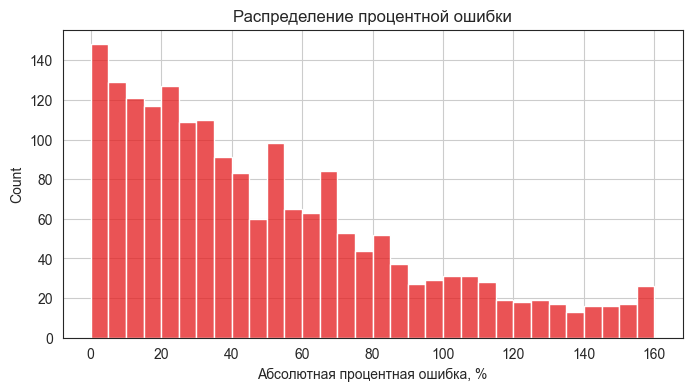

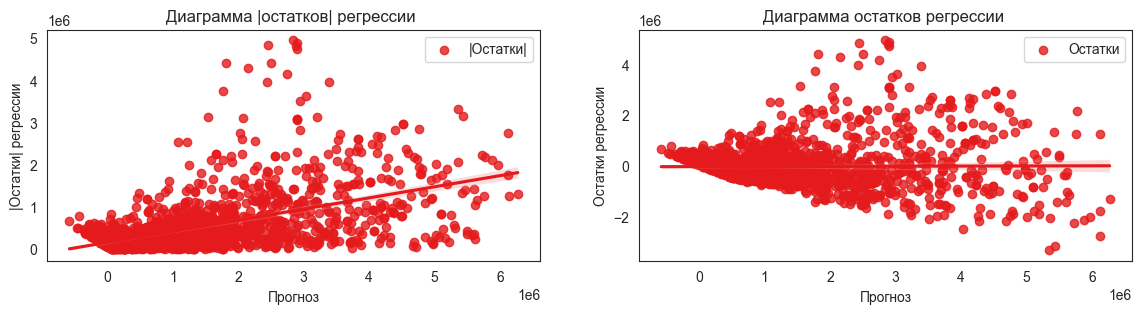

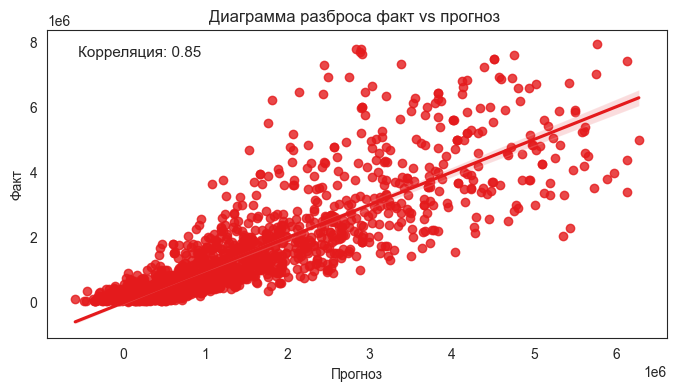

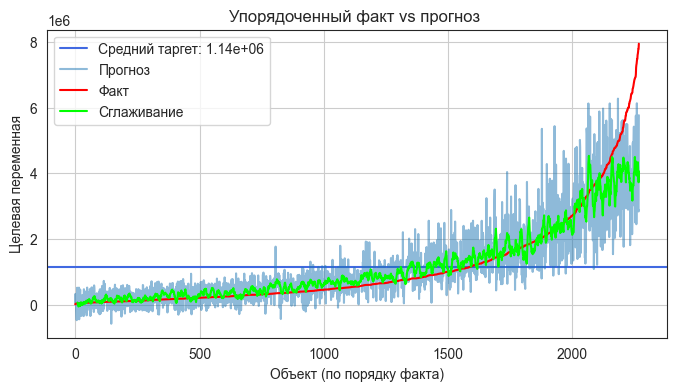

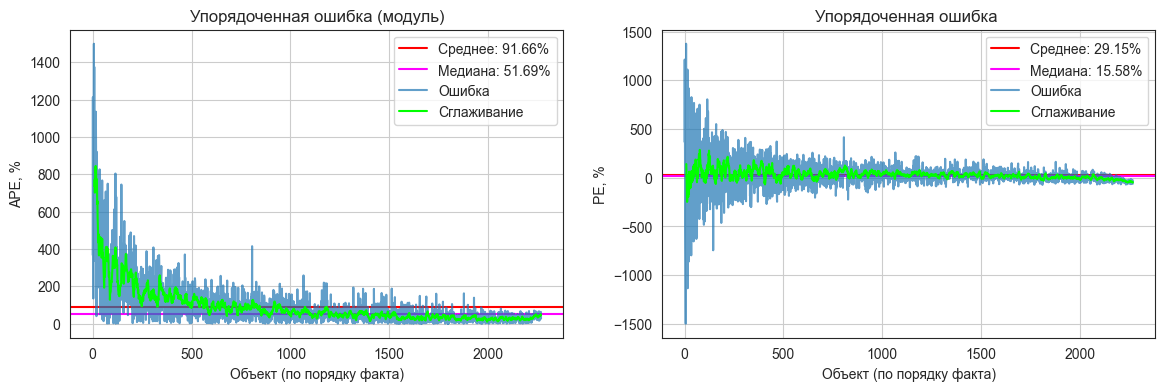

In [22]:
params = study.best_trial.params
params.update(FIXED_KWARGS)

model = Ridge(**params).fit(X_train_base, y_train)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

## CatBoost

train metrics:
	  R2: 92.78%
	RMSE: 386539.96 руб.
	MAPE: 33.55%

test metrics:
	  R2: 84.35%
	RMSE: 567461.57 руб.
	MAPE: 39.33%


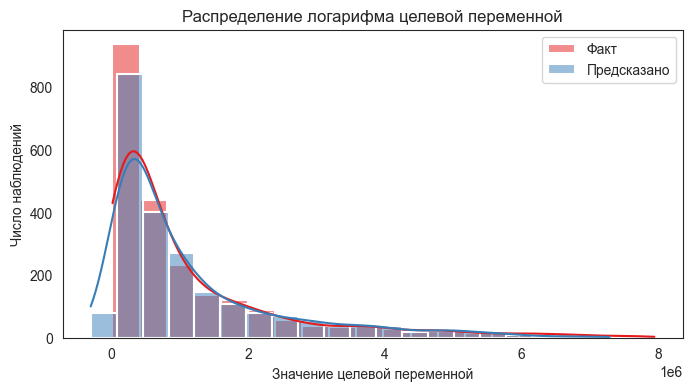

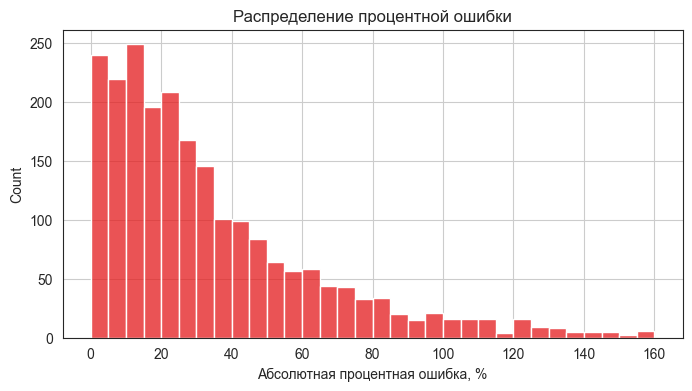

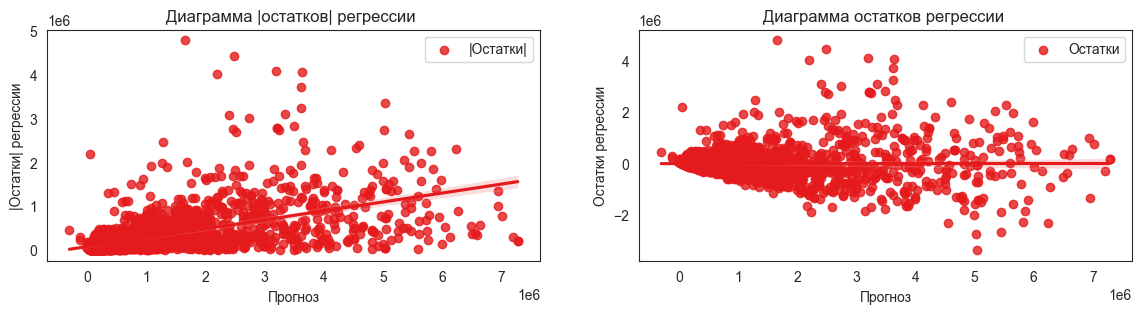

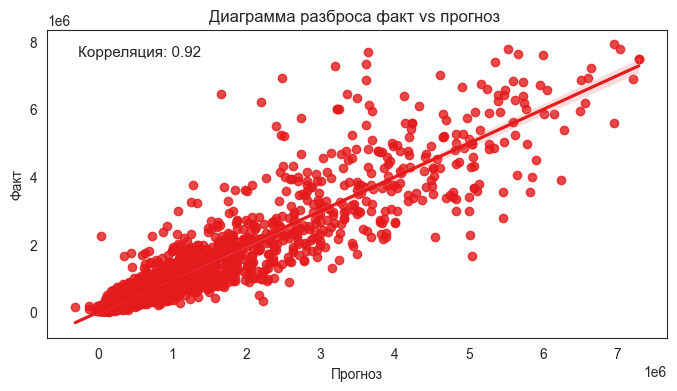

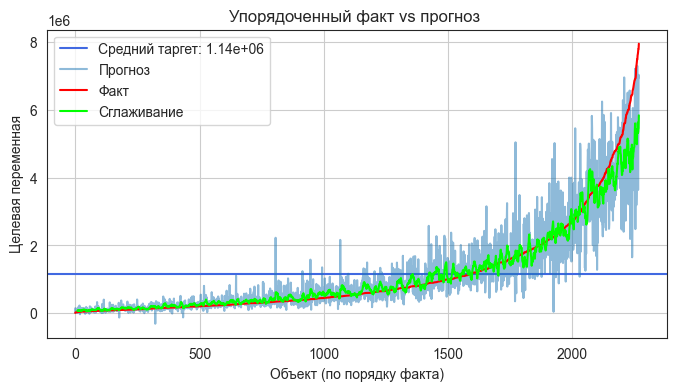

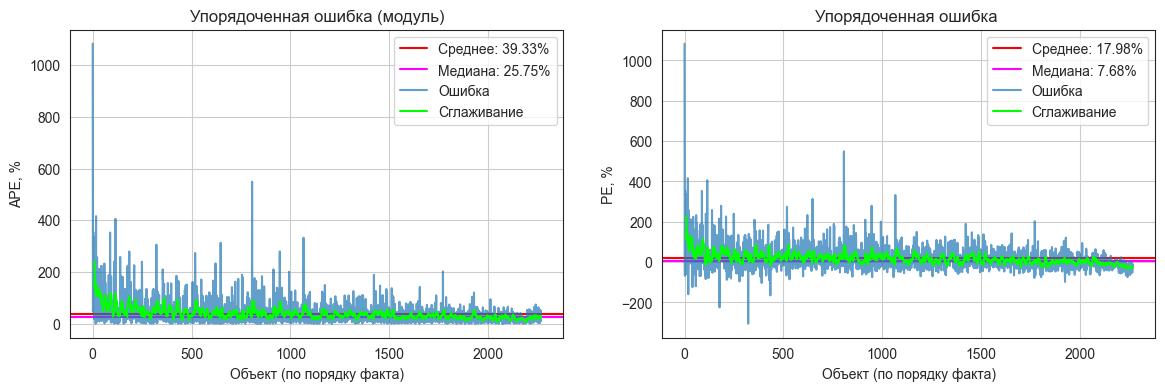

In [24]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [25]:
FIXED_KWARGS = {
    'logging_level': 'Silent',
    'loss_function': 'RMSE',
    'random_state': 10,
}

def objective(trial, X, y):
    params = {
        'iterations': trial.suggest_categorical('iterations', [50, 100, 200, 300, 500, 750, 1000]),
        'depth': trial.suggest_int('depth', low=3, high=6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', low=1e-6, high=100.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', low=1e-4, high=5e-1), # log=True
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', low=5, high=25),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        'subsample': trial.suggest_float('subsample', low=0.3, high=1.0),
        'early_stopping_rounds': 200,
    }
    
    params.update(FIXED_KWARGS)
    model = CatBoostRegressor(**params).fit(X, y)
    scores = cross_validate(
        model,
        X, y,
        scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
        cv=CV,
        n_jobs=-1,
    )
    return scores['test_score'].mean()

In [26]:
study = optuna.create_study(
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.HyperbandPruner(),
        direction="maximize",
)

study.optimize(lambda trial: objective(trial, X_train_base, y_train),
                  n_trials=1000, timeout=600, gc_after_trial=True, show_progress_bar=True)

study_results(study)
plot_study(study)

  0%|          | 0/1000 [00:00<?, ?it/s]

[W 2025-12-24 13:05:24,413] Trial 0 failed with parameters: {'iterations': 50, 'depth': 3, 'l2_leaf_reg': 0.00817052630267235, 'learning_rate': 0.1033626791493023, 'min_data_in_leaf': 18, 'colsample_bylevel': 0.36572760887291184, 'subsample': 0.6214147148587048} because of the following error: AttributeError("The following error was raised: 'CatBoostRegressor' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.").
Traceback (most recent call last):
  File "C:\Users\User\miniconda3\Lib\site-packages\sklearn\utils\_tags.py", line 275, in get_tags
    tags = estimator.__sklearn_tags__()
           ^^

AttributeError: The following error was raised: 'CatBoostRegressor' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [ ]:
params = study.best_trial.params
params.update(FIXED_KWARGS)

model = CatBoostRegressor(**params).fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)